#BRAZILIAN E-COMMERCE ANALYSIS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
customer = pd.read_csv('/content/olist_customers_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
orders = pd.read_csv('/content/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')

In [ ]:
# Monthly Revenue

mr = pd.read_csv('/content/monthly revenue.csv', header = None)
mr.columns =['Months', 'Revenue']
month_names = {1 : 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6: 'June', 7: 'July', 8 : 'Aug', 9 : 'Sep', 10 : 'Oct', 11 : 'Nov', 12 : 'Dec'}
mr['Months'] = mr['Months'].map(month_names)
mr

,Months,Revenue
0,Jan,115.803728
1,Feb,113.125057
2,Mar,120.263432
3,Apr,126.414368
4,May,124.164799
5,June,121.725996
6,July,118.600754
7,Aug,116.699585
8,Sep,128.224545
9,Oct,124.328280


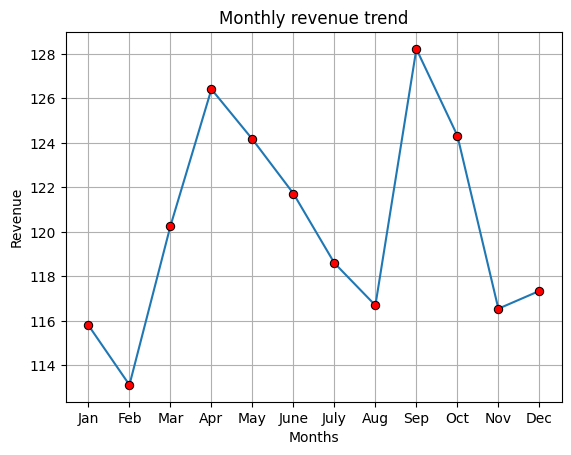

In [ ]:
# Visualising Monthly Revenue Trend

sns.lineplot(data = mr, x = 'Months', y = 'Revenue', marker = '.', markersize = (12), markerfacecolor = 'red', markeredgecolor = 'black')
plt.title('Monthly revenue trend')
plt.grid()
plt.show()

## MONTHLY REVENUE TREND
### Key Insights
- 2016 was excluded from monthly trend analysis because the dataset contains only partial-year data, making month-to-month comparisons unreliable.
- Revenue generally increased over observed period.
- Sales peaked in April and September.



In [ ]:
# State Revenues

sr = pd.read_csv('/content/state revenues.csv', header = None)
sr.columns = ['States', 'Revenue']
sr['Revenue (in Millions)'] = sr['Revenue']/1000000
sr.drop(columns = {'Revenue'}, axis = 0, inplace = True)
sr.head(5)

,States,Revenue (in Millions)
0,AC,0.015931
1,AL,0.078806
2,AM,0.022156
3,AP,0.013375
4,BA,0.493339


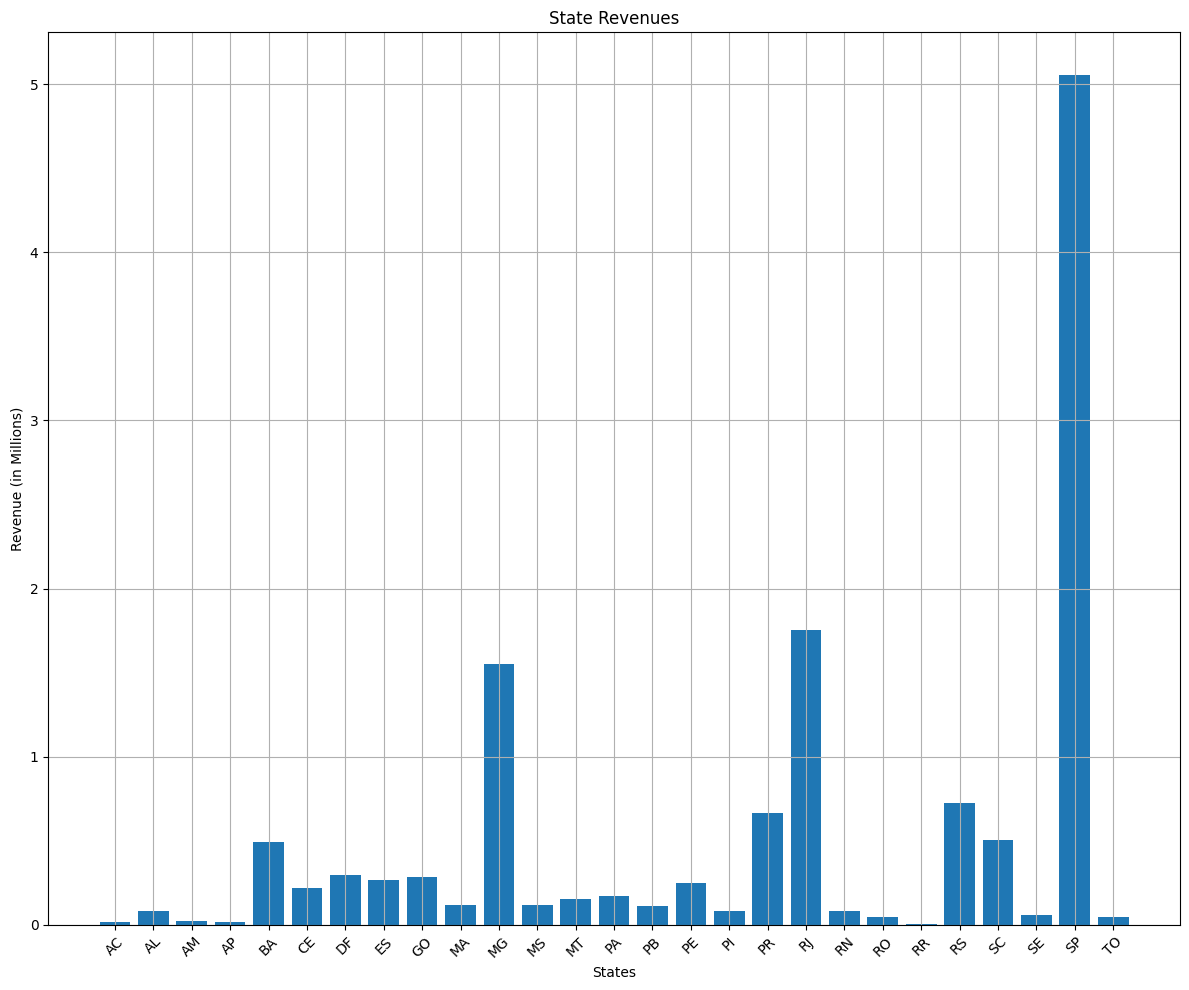

In [ ]:
# Visualising State Revenues

plt.figure(figsize = (12, 10))
plt.bar( sr['States'], sr['Revenue (in Millions)'])
plt.title('State Revenues')
plt.xlabel('States')
plt.ylabel('Revenue (in Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

# STATE REVENUES
## Key Insights
- SP (Sao Paulo), MG (Minas Gerais) and RJ (Rio de Janeiro) generated the highest revenues but SP is subtantially higher than the other two.
- Revenue is concentrated among small number of states.

In [ ]:
# Top 10 Product Categories by Revenue

pc = pd.read_csv('/content/top categories by revenue.csv', header= None)
pc.columns = ['Product Category', 'Revenue(in Millions)']
pc['Revenue(in Millions)'] =pc['Revenue(in Millions)']/1000_000
pc.head(5)

,Product Category,Revenue(in Millions)
0,beleza_saude,1.233132
1,relogios_presentes,1.166177
2,cama_mesa_banho,1.023435
3,esporte_lazer,0.954853
4,informatica_acessorios,0.888725


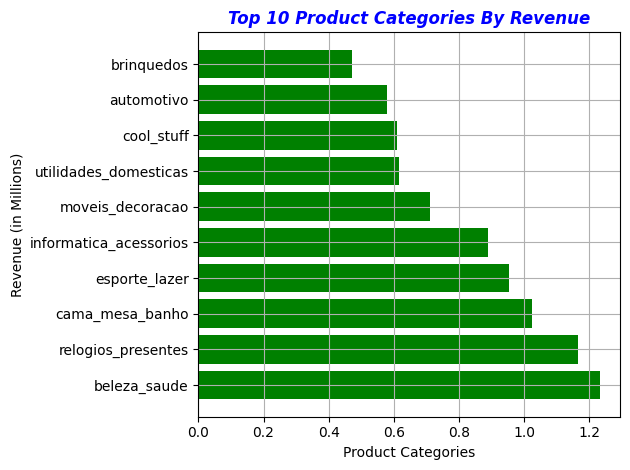

In [ ]:
# Visualising top 10 Product Categories by Revenue

plt.barh(pc['Product Category'], pc['Revenue(in Millions)'], color = 'green')
plt.title('Top 10 Product Categories By Revenue', fontweight = 'bold', fontstyle = 'italic', color = 'blue')
plt.xlabel('Product Categories')
plt.ylabel('Revenue (in Millions)')
plt.tight_layout()
plt.grid()
plt.show()

# Top 10 Product Categories by Revenue
## Key Insights
- Beauty and Health generated the highest revenue.
- The top 10 categories contributed 62.36% of the total revenue.
- Revenue is concentrated among small number of categories.

In [ ]:
# Order Status Distribution

os = pd.read_csv('/content/order statuses.csv', header = None)
os.columns = ['Order Status', 'Total Count', 'Percentage']
os

,Order Status,Total Count,Percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


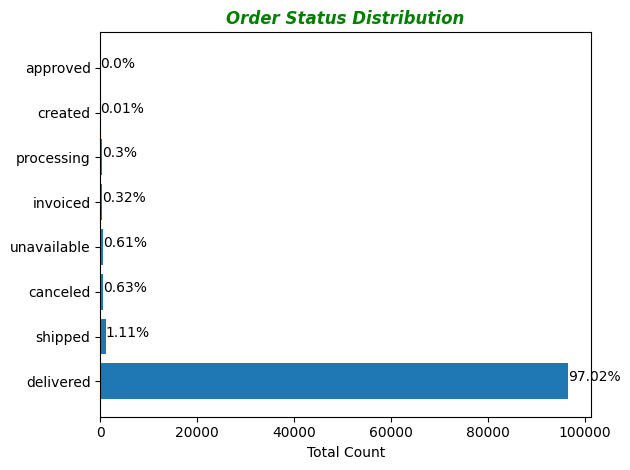

In [ ]:
# Visualising Order Status Distribution

bars = plt.barh(os['Order Status'], os['Total Count'])
for i, pct in enumerate(os['Percentage']):
    plt.text(os['Total Count'][i], i, f'{pct}%')
plt.title('Order Status Distribution', fontstyle = 'italic', fontweight = 'bold', color = 'green')
plt.xlabel('Total Count')
plt.tight_layout()
plt.show()

# Order Status Distribution
## Key Insights
- More than 97% of all orders were delivered successfully.
- Cancelled and Unavailable order rates are very low.
- An investigation of products' dimensions and freight value didnt show a strong relationship with product delays.
- Overall delivery performance appears highly reliable.

In [ ]:
# One time vs Repeat Customers
# This data is taken from sql findings

vs = pd.DataFrame({'Customer Type': ['One-time customer', 'Repeat Customer'], 'Total Count' : [90557, 2801], 'Percentage' : [97,3]})
vs

,Customer Type,Total Count,Percentage
0,One-time customer,90557,97
1,Repeat Customer,2801,3


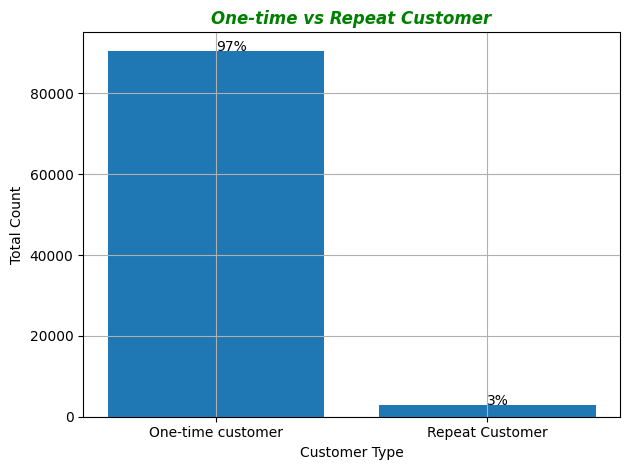

In [ ]:
# Visualising One time vs Repeat Customers

bars = plt.bar(vs['Customer Type'], vs['Total Count'])
for i, pct in enumerate(vs['Percentage']):
  plt.text(i, vs['Total Count'][i], f'{pct}%')
plt.title('One-time vs Repeat Customer', fontstyle = 'italic', fontweight = 'bold', color = 'green')
plt.xlabel('Customer Type')
plt.ylabel('Total Count')
plt.grid()
plt.tight_layout()
plt.show()

# One time vs Repeat Customers
## Key Insights
- Customer retention seems really weak with only 3% retention rate.
- Average revenue per One-time customer = 137.96
- Average revenue per Repeat customer = 260.05
- Repeat customers generate 1.884 times more revenue than One-time customers.
- Customer retention seems to be a major growth opportunity.

In [ ]:
# Popularity vs Profitability
pop = pd.read_csv('/content/popularity vs profitability.csv', header = None)
pop = pop.head(10)
pop.columns = ['Product Category Name', 'Popularity', 'Profitability (in Millions)']
pop['Profitability (in Millions)'] = pop['Profitability (in Millions)']/1000_000
pop.head(5)

,Product Category Name,Popularity,Profitability (in Millions)
0,beleza_saude,9465,1.233132
1,relogios_presentes,5859,1.166177
2,cama_mesa_banho,10953,1.023435
3,esporte_lazer,8431,0.954853
4,informatica_acessorios,7644,0.888725


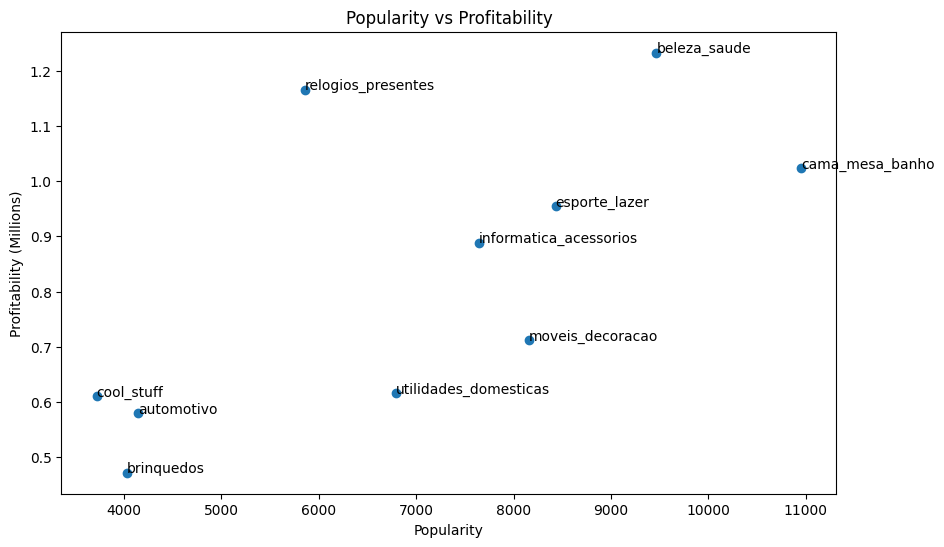

In [ ]:
# Visualising Popularity vs Profitability

plt.figure(figsize=(10,6))

plt.scatter(pop['Popularity'], pop['Profitability (in Millions)'])

for i in range(len(pop)):
    plt.annotate(
        pop['Product Category Name'][i],
        ( pop['Popularity'][i], pop['Profitability (in Millions)'][i]))

plt.xlabel('Popularity')
plt.ylabel('Profitability (Millions)')
plt.title('Popularity vs Profitability')

plt.show()

# Popularity vs Profitability
## Key Insights
- Popularity vs Profitability dont always move together.
- Some categories despite being less popular generated very high revenue.
- Both demand and revenue should be evaluated properly before prioritizing product categories.

In [ ]:
# Pareto chart for top revenue categories
rc = pd.read_csv('/content/revenue concentration.csv', header = None)
rc.columns = ['Product Category Name', 'Revenue (in Millions)', 'Cumulative Revenue (in Millions)',
              'Cumulative Revenue Percentage']
rc['Revenue (in Millions)'] = rc['Revenue (in Millions)']/1000_000
rc['Cumulative Revenue (in Millions)'] = rc['Cumulative Revenue (in Millions)']/1000_000
rc.head(5)

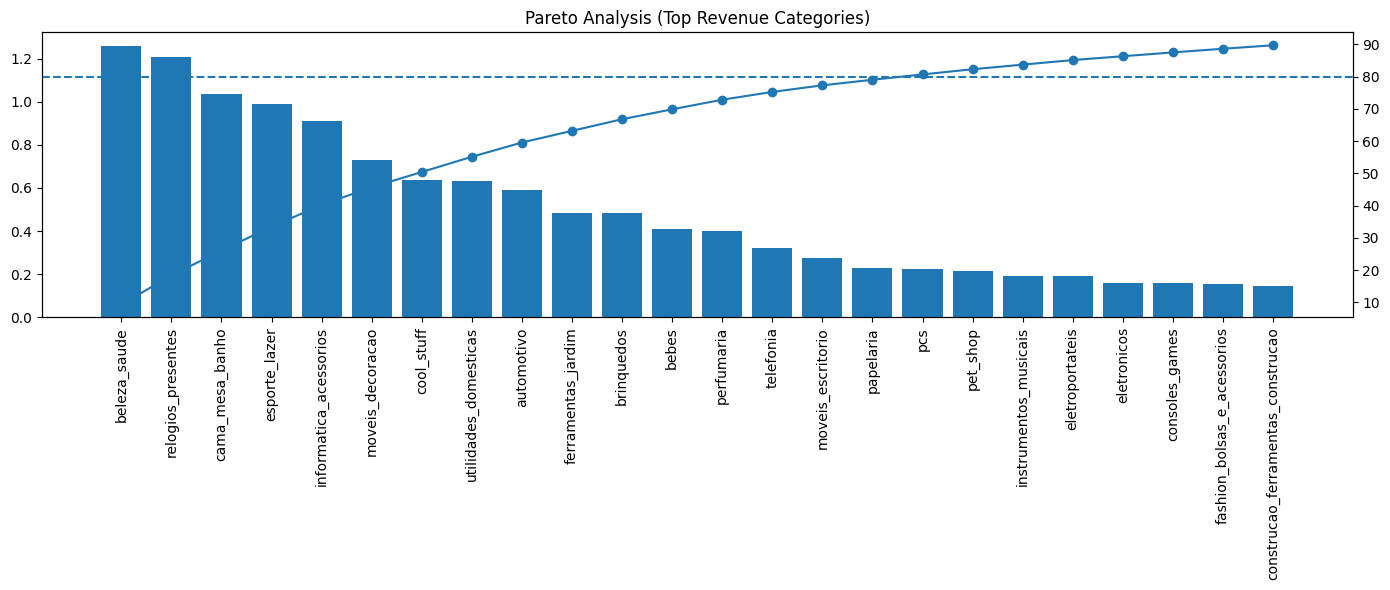

In [ ]:
# Visualising the Pareto chart
rc_90 = rc[rc['Cumulative Revenue Percentage'] <= 90]
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(rc_90['Product Category Name'], rc_90['Revenue (in Millions)'])

ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()

ax2.plot(rc_90['Product Category Name'], rc_90['Cumulative Revenue Percentage'], marker='o')

ax2.axhline(y=80, linestyle='--')

plt.title('Pareto Analysis (Top Revenue Categories)')
plt.tight_layout()
plt.show()

# Pareto Analysis (Top Revenue Categories)
## Key Insights
- Revenue follows Pareto-like distribution.
- Top 24 categories contribute to 90% of the total revenue.
- Focusing on these limited number of categories could give majority of business results.

# Final Conclusion
- Total Revenue exceeded 13.5 million.
- Revenue seems to generally grow throughout the year.
- Majority of the revenue is generated by few States and Product Categories.
- Customer Retention seems extremely weak with most of the customers purchasing only once.
- Repeat customers generate higher revenue than One-time customers.
- Delivery services are highly reliable.
- Top 25 categories generate approximately 90% of total revenue.